<a href="https://colab.research.google.com/github/elenaaalmg/OptimizacionImagenes/blob/main/coeficientesFourier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

## **Función a aproximar**

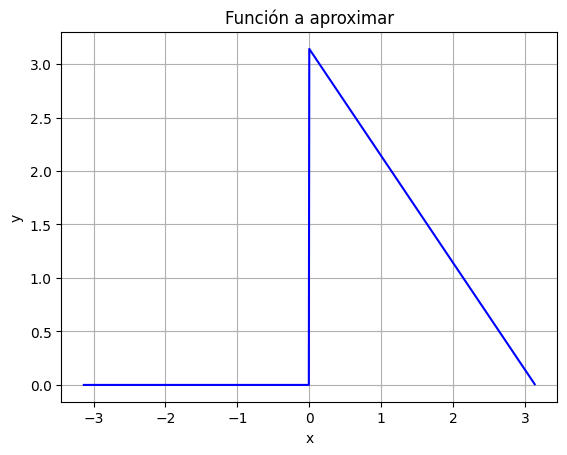

In [ ]:
def f(x):
  if x > -np.pi and x < 0:
    return 0

  if x >= 0 and x < np.pi:
    return np.pi - x

x = np.linspace(-np.pi, np.pi, 1000, endpoint = False)[1:] # dominio de los datos
y = np.zeros_like(x)

for i in range (len(x)):
  y[i] = f(x[i])

plt.plot(x, y, color = "blue")
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.title("Función a aproximar")
plt.show()

## **Calculo de los coeficientes de la serie de fourier**

Para realizar el calculo de los coeficientes de la serie de fourier utilizaremos dos alternativas que siguen el método de mínimos cuadrados.

### **Ecuaciones normales asociadas**

La primera alternativa consiste en resolver de forma "manual" el sistema de ecuaciones de la forma Ac =  y, donde:

**A** : matriz que contiene los valores de las funciones base (para este caso, senos y cosenos) evaluadas en los puntos x

**c** : vector de coeficientes desconocidos que queremos encontrar (a_n, b_n)

**y** : vector de valores de la función que estamos ajustando

Recordemos que el objetivo es encontrar una combinación lineal de funciones que aproxime mejor nuestros datos.

[0.78702053 0.63966032 0.99999671 0.00324473 0.49999342 0.07377608
 0.33332346 0.00324473 0.24998684 0.02850534 0.19998355]


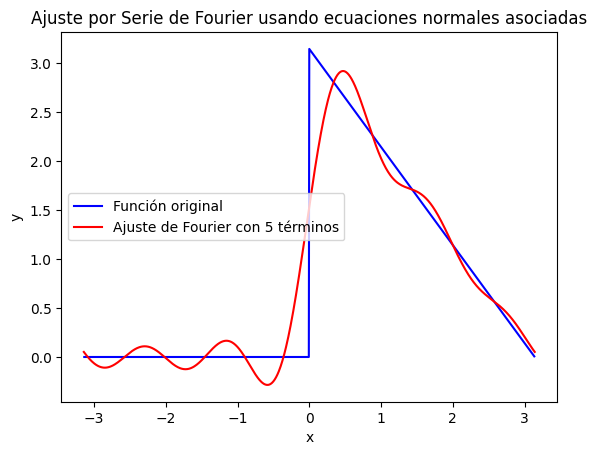

In [ ]:
N = 5 # número de terminos para la serie de fourier

# construimos la matriz de funciones:
# tendremos tantas filas como puntos de datos tengamos
# la columna 0 está destinada a representar el término a0/2
# para cada frecuencia n de 1 a N agregamos dos columnas (una para an y otra para bn)
# entonces para N términos en la serie, tenemos una columna para el término cte y dos para cada par de funciones sen y cos
A = np.ones((len(x), 2*N + 1))

# llenado de la matriz A con senos y cosenos
# el llenado se hace de forma salteada uno y uno, es decir, llena un cos para a_n, seguido de un sen para b_n y así hasta N + 1
for n in range(1, N + 1):
    A[:, 2*n - 1] = np.cos(n*x)  # Columna para a_n
    A[:, 2*n] = np.sin(n*x)      # Columna para b_n

# resolveremos el sistema de ecuaciones despejando c de nuestra ecuación Ac = y, entonces c = (A^-1)*y
# como estamos hablando de matrices, A^-1 hacereferencia a la matriz inversa, pero como A no siempre es cuadrada,
# debemos hacer uso de la pseudoinversa
c = np.linalg.pinv(A) @ y # producto de matrices

# función que calcula la serie de fourier con los coeficientes encontrados para aproximar la función
def fourierSeries(x, c, N):
    result = c[0] # término constante a_0/2
    for n in range(1, N + 1):
        result += c[2*n - 1]*np.cos(n*x) + c[2*n]*np.sin(n*x)
    return result


# mostramos los coeficientes encontrados
print("Coeficientes de Fourier:")
print("a_0/2 =", c[0])
for i in range(1, N + 1):
    print(f"a_{i} = {c[2*i - 1]}, b_{i} = {c[2*i]}")

print("\n")

# generamos los valores ajustados para graficar
x_ = np.linspace(-np.pi, np.pi, 1000) # ojo que este debe ser igual al dominio de los datos originales para obtener una mejor aproximación de los coeficientes
y_ = fourierSeries(x_, c, N)

plt.plot(x, y, label = "Función original", color = "blue")
plt.plot(x_, y_, color = "red", label = f"Ajuste de Fourier con {N} términos")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Ajuste por Serie de Fourier usando ecuaciones normales asociadas")
plt.show()


### **Curve_fit**

La otra alternativa que usaremos para encontrar los coeficientes es usando una función de scipy que utiliza minimos cuadrados no lineales para ajustar una función a los datos.

Coeficientes de Fourier:
a_0/2 = 0.7870205280767061
a_1 = 0.6396603230664099, b_1 = 0.9999967103428766
a_2 = 0.0032447292362737918, b_2 = 0.4999934204391266
a_3 = 0.07377608070859115, b_3 = 0.33332346376881405
a_4 = 0.0032447288820626054, b_4 = 0.24998684018681253
a_5 = 0.028505341388010103, b_5 = 0.19998355022720474




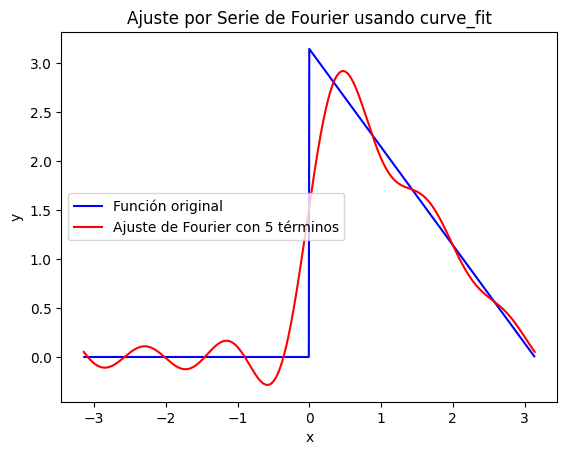

In [ ]:
N = 5 # numero de términos de la serie de fourier

# función que calcula la serie de fouerier para aproximar la función
def fourierSeries(x, *coeffs):
    result = coeffs[0]
    for n in range(1, N + 1):
        result += coeffs[2*n - 1]*np.cos(n*x) + coeffs[2*n]*np.sin(n*x)
    return result

y0 = [0]*(2*N + 1) # condiciones iniciales

# econtrando los coeficientes de la serie de fourier que se ajusta a la función original
c, _ = curve_fit(fourierSeries, x, y, p0 = y0)

# mostramos los coeficientes encontrados
print("Coeficientes de Fourier:")
print("a_0/2 =", c[0])
for i in range(1, N + 1):
    print(f"a_{i} = {c[2*i - 1]}, b_{i} = {c[2*i]}")

print("\n")

# generamos los valores ajustados para graficar
x_ = np.linspace(-np.pi, np.pi, 1000) # ojo que este debe ser igual al dominio de los datos originales para obtener una mejor aproximación de los coeficientes
y_ = fourierSeries(x_, *c)

plt.plot(x, y, label = "Función original", color = "blue")
plt.plot(x_, y_, color = "red", label = f"Ajuste de Fourier con {N} términos")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Ajuste por Serie de Fourier usando curve_fit")
plt.show()

